# Part 1 — Exploratory Data Analysis: Login Demand

**Goal:** aggregate raw login timestamps into 15-minute intervals, characterize the time series (daily/weekly cycles), and flag data quality issues.


In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

with open('../data/logins.json') as f:
    data = json.load(f)

logins = pd.Series(pd.to_datetime(data['login_time']))
print(f"{len(logins):,} login events")
print(f"Range: {logins.min()} to {logins.max()}")
print(f"Unique calendar dates spanned: {logins.dt.date.nunique()}")

93,142 login events
Range: 1970-01-01 20:12:16 to 1970-04-13 18:57:38
Unique calendar dates spanned: 103


## 1.1 Aggregate to 15-minute intervals

In [2]:
df = logins.to_frame('login_time').set_index('login_time').sort_index()
df['count'] = 1

# resample onto a fixed 15-min grid (fills any interval with zero logins as 0)
ts = df['count'].resample('15min').sum()
print(f"{len(ts):,} fifteen-minute intervals")
ts.describe()

9,788 fifteen-minute intervals


count    9788.000000
mean        9.515938
std         8.328818
min         0.000000
25%         3.000000
50%         7.000000
75%        13.000000
max        73.000000
Name: count, dtype: float64

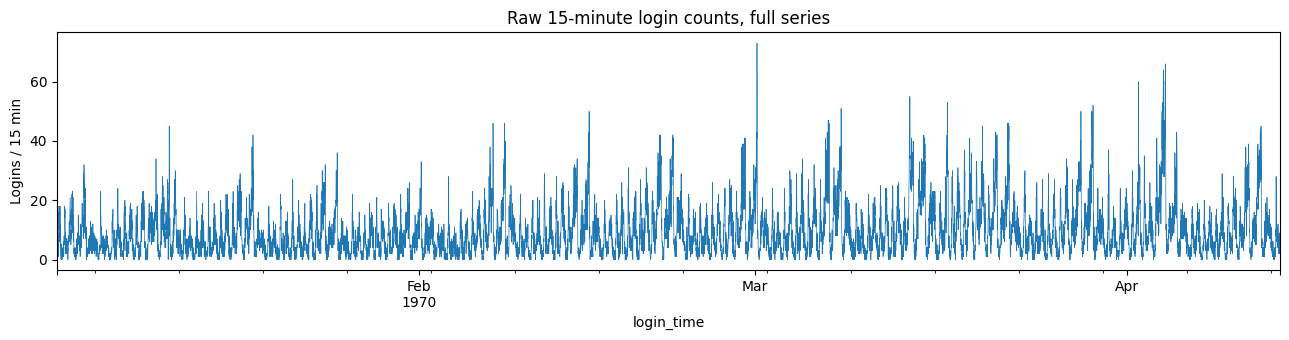

In [3]:
fig, ax = plt.subplots(figsize=(13,3.5))
ts.plot(ax=ax, lw=0.5)
ax.set_title('Raw 15-minute login counts, full series')
ax.set_ylabel('Logins / 15 min')
plt.tight_layout()
plt.show()

The raw 15-minute series is too dense to read as a line chart. Daily totals make the
underlying weekly cycle and growth trend much clearer.

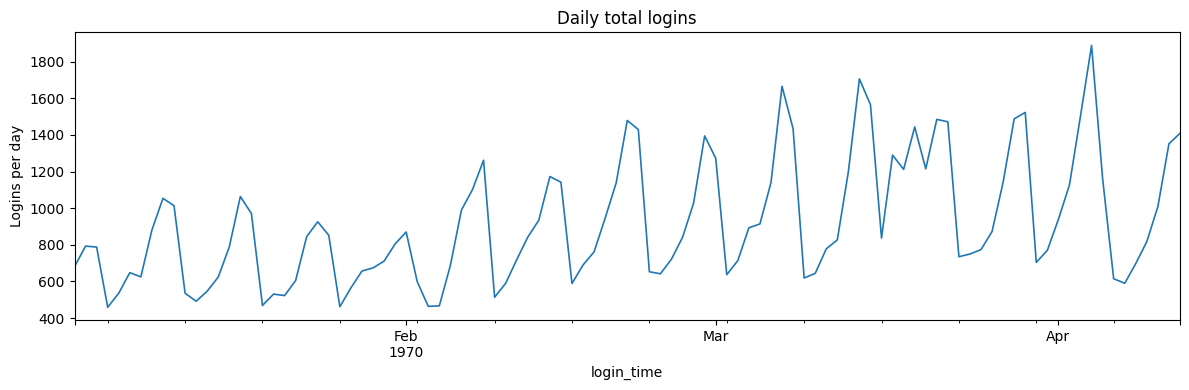

In [4]:
daily = df['count'].resample('D').sum()

fig, ax = plt.subplots(figsize=(12,4))
daily.iloc[1:-1].plot(ax=ax, lw=1.2)   # drop first/last (partial) calendar day - see Data Quality below
ax.set_title('Daily total logins')
ax.set_ylabel('Logins per day')
plt.tight_layout()
plt.show()

**Observations:**
- A clean **7-day cycle** is visible throughout — the same rhythm repeats every week.
- There is a steady **upward trend** in overall volume across the ~101 full days in the series (roughly from ~700/day at the start to ~1,400-1,900/day at the end), consistent with a market in a growth phase.
- One week (~day 45) breaks the pattern with an unusually shallow peak — flagged in Data Quality below.


## 1.2 Daily cycle: weekday vs. weekend

Because the timestamps are anonymized onto the Unix epoch (starting 1970‑01‑01, a Thursday),
`day of week` is still meaningful — it's just been shifted so day 1 of the dataset lines up with
Jan 1, 1970 rather than the true calendar date. Grouping by `dayofweek` therefore recovers the
real weekly rhythm.

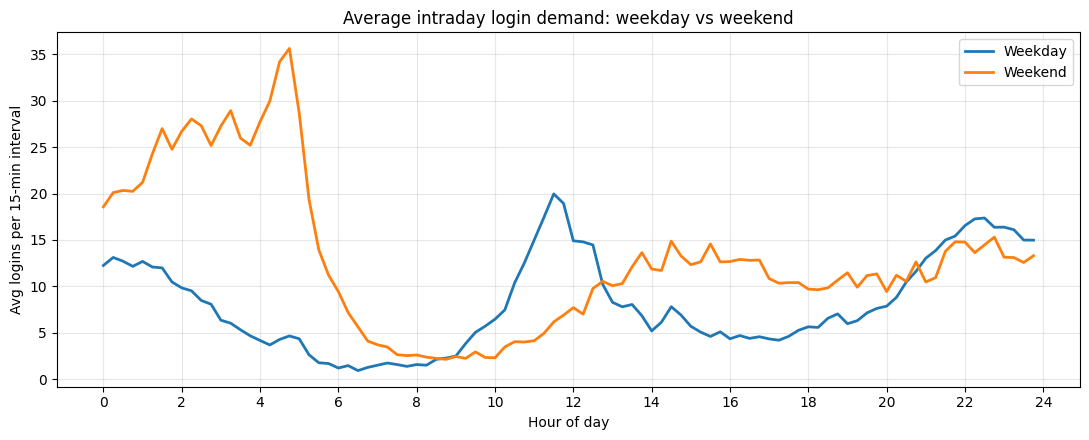

In [5]:
ts_df = ts.to_frame('logins')
ts_df['dow'] = ts_df.index.dayofweek           # 0=Mon ... 6=Sun
ts_df['is_weekend'] = ts_df['dow'] >= 5
ts_df['minute_of_day'] = ts_df.index.hour*60 + ts_df.index.minute

intraday = ts_df.groupby(['is_weekend','minute_of_day'])['logins'].mean().unstack(level=0)
intraday.columns = ['Weekday','Weekend']

fig, ax = plt.subplots(figsize=(11,4.5))
x = intraday.index/60
ax.plot(x, intraday['Weekday'], label='Weekday', lw=2)
ax.plot(x, intraday['Weekend'], label='Weekend', lw=2)
ax.set_xticks(range(0,25,2))
ax.set_xlabel('Hour of day'); ax.set_ylabel('Avg logins per 15-min interval')
ax.set_title('Average intraday login demand: weekday vs weekend')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Two very different demand shapes:**
- **Weekdays** show a single broad midday peak (~11:00–12:00, ~20 logins/15-min) that looks like
  errands/commute-adjacent travel, a sharp trough overnight (bottoms out ~06:30, <1/interval), and
  a secondary rise in the evening (21:00–23:00) as weekday nightlife picks up.
- **Weekends** peak overnight instead — demand climbs from midnight and **peaks around 04:45**
  (~36 logins/15-min, the single highest average slot in the dataset), then collapses to the
  week's quietest stretch by 07:00–09:00, before slowly rebuilding through the afternoon and evening.

This is the classic late-night-nightlife-vs-daytime-errands demand split described in Part 2:
weekday demand looks daytime-oriented while weekend demand is dominated by very-late-night rides.

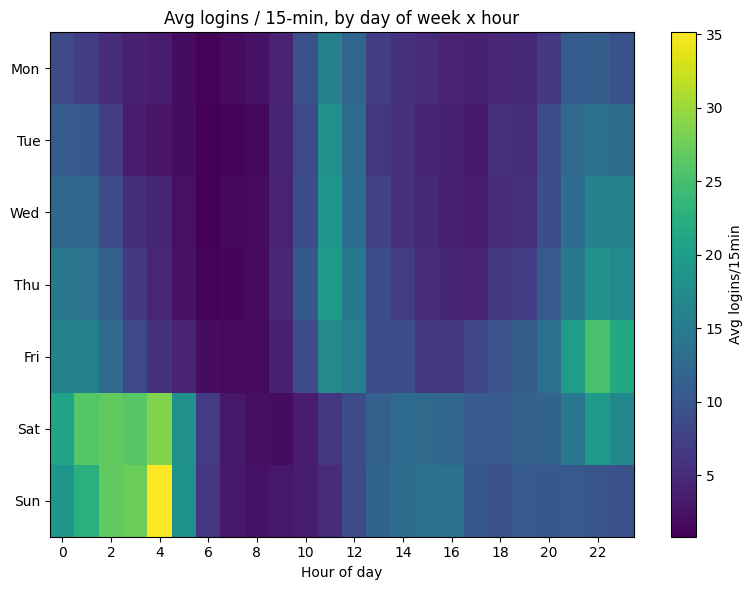

In [6]:
ts_df['hour'] = ts_df.index.hour
heat = ts_df.groupby(['dow','hour'])['logins'].mean().unstack(level=0)
heat.columns = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(heat.T.values, aspect='auto', cmap='viridis')
ax.set_yticks(range(7)); ax.set_yticklabels(heat.columns)
ax.set_xticks(range(0,24,2)); ax.set_xticklabels(range(0,24,2))
ax.set_xlabel('Hour of day'); ax.set_title('Avg logins / 15-min, by day of week x hour')
plt.colorbar(im, ax=ax, label='Avg logins/15min')
plt.tight_layout()
plt.show()

The heatmap shows the Friday/Saturday-night surge bleeding into the small hours of Saturday/
Sunday (note: because days are cut at midnight, "Saturday 2–5am" activity is really an extension
of Friday night, and "Sunday 2–5am" is an extension of Saturday night — worth keeping in mind when
communicating this to a non-technical audience).

## 1.3 Data quality issues

In [7]:
# 1) Partial boundary days
print("First day total:", daily.iloc[0], " | last day total:", daily.iloc[-1],
      " vs. full-day median:", daily.iloc[1:-1].median())

# 2) Exact-second duplicate timestamps
dupe_rows = pd.Series(data['login_time']).duplicated(keep=False).sum()
print(f"Rows sharing an exact-second timestamp with another row: {dupe_rows:,} "
      f"({dupe_rows/len(data['login_time']):.1%} of all logins)")

# 3) Zero-count 15-min intervals
print(f"15-min intervals with zero logins: {(ts==0).sum():,} ({(ts==0).mean():.1%})")

First day total: 112  | last day total: 395  vs. full-day median: 837.0
Rows sharing an exact-second timestamp with another row: 1,745 (1.9% of all logins)
15-min intervals with zero logins: 407 (4.2%)


- **Truncated boundary days.** The series starts at 20:12 on day 1 and ends at 18:57 on the
  final day, so the first (112 logins) and last (395 logins) calendar days are partial and not
  comparable to full days (median ~840/day) — they were excluded from the daily-total chart above
  and should be excluded from any day-level modeling.
- **No real calendar dates or timezone.** Timestamps are anonymized onto the Unix epoch with no
  location or timezone metadata, so the mid-February dip and the overall growth trend can't be
  tied to a specific real-world date, holiday, or weather event without additional context from
  whoever provided the export.
- **Exact-second duplicate timestamps (~1.9% of rows).** At this volume, a small number of
  same-second collisions is expected by chance during busy periods, but the rate is worth a
  sanity check with the source system to rule out duplicate/retried log events rather than
  simultaneous distinct logins.
- **15-min intervals with zero logins (~4%).** These cluster almost entirely in the weekday
  06:00–09:00 trough, which reads as genuine low demand rather than a data gap, since the
  resampled grid has no missing timestamps.
